### Tenrec Dataset EDA

QB-Video is a much smaller version of QK-Video (which literally broke my computer)

Actually, QB is from a different, smaller application, but the formatting of both entries are the same.

QB-Video includes interaction data from about 30,000 unique users, in the format of:

{user_id, item_id, click, follow, like, share, video_category, watching_times, gender, age}

user_id: unique identifier

item_id: video identifier presented to user

click, follow, like, share are all binary, 0: no action, 1: action

video_category: NULL, 0, 1
    -The category is unknown, for data privacy reasons

watching_times: Number of times the user re-watched the video

Gender: 0, 1, 2
    0: presumed unknown or null,
    1: likely male
    2: likely female

Age: 0 to 7, in bins of 10 years
    0: presumed unknown
    1: 10-19 years old
    2: 20-29 years old
    3: 30-39 years old
    4: 40-49 years old
    5: 50-59 years old
    6: 60-69 years old
    7: 70-79 years old

There are no direct timestamps, again for privacy reasons, but each entry in the table is in sequential order, so we can still get relative temporal data.

There are many different recommendation system problems that this dataset can be used for, but I'd like to focus one one classifiation (CTR) and recommendation (SBR). Click through rate is a classification problem because we want to predict if a given user and piece of content will result in a click. Each user and item pair is treated independently. Session based recommendation is a recommendation problem, where we want to predict the next item a user will interact with given their previous behavior.

First, let's create some simple visualizations

In [9]:
import polars as pl
import matplotlib.pyplot as plt
DATA_PATH = "../data/sbr_data_1M.csv"

df = pl.scan_csv(DATA_PATH, null_values=["\\N"]).collect()
print(df.head(10))


shape: (10, 10)
┌─────────┬─────────┬───────┬────────┬───┬────────────────┬────────────────┬────────┬─────┐
│ user_id ┆ item_id ┆ click ┆ follow ┆ … ┆ video_category ┆ watching_times ┆ gender ┆ age │
│ ---     ┆ ---     ┆ ---   ┆ ---    ┆   ┆ ---            ┆ ---            ┆ ---    ┆ --- │
│ i64     ┆ i64     ┆ i64   ┆ i64    ┆   ┆ i64            ┆ i64            ┆ i64    ┆ i64 │
╞═════════╪═════════╪═══════╪════════╪═══╪════════════════╪════════════════╪════════╪═════╡
│ 1       ┆ 1       ┆ 1     ┆ 0      ┆ … ┆ 1              ┆ 1              ┆ 1      ┆ 4   │
│ 1       ┆ 2       ┆ 1     ┆ 0      ┆ … ┆ 1              ┆ 1              ┆ 1      ┆ 4   │
│ 1       ┆ 3       ┆ 1     ┆ 0      ┆ … ┆ 0              ┆ 1              ┆ 1      ┆ 4   │
│ 1       ┆ 80936   ┆ 1     ┆ 0      ┆ … ┆ 1              ┆ 1              ┆ 1      ┆ 4   │
│ 1       ┆ 781     ┆ 1     ┆ 0      ┆ … ┆ 1              ┆ 1              ┆ 1      ┆ 4   │
│ 1       ┆ 111774  ┆ 1     ┆ 0      ┆ … ┆ 1              ┆ 1   

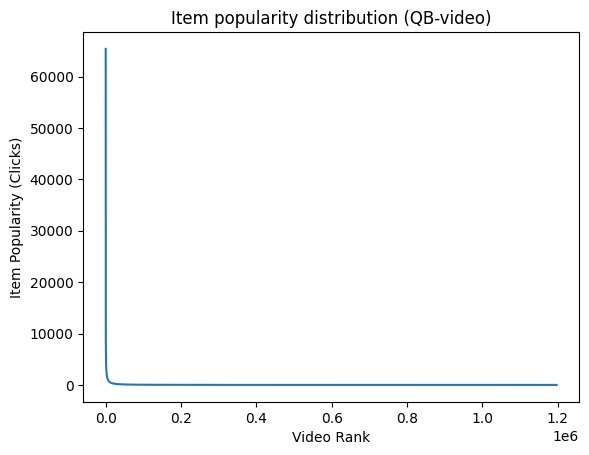

In [2]:
item_pop = df.group_by("item_id").agg(pl.sum("click").alias("num_clicks")).sort("num_clicks", descending=True).with_row_index("video_rank").collect()

plt.figure()
plt.plot(item_pop["video_rank"], item_pop["num_clicks"])
plt.xlabel("Video Rank")
plt.ylabel("Item Popularity (Clicks)")
plt.title("Item popularity distribution (QB-video)")
plt.show()

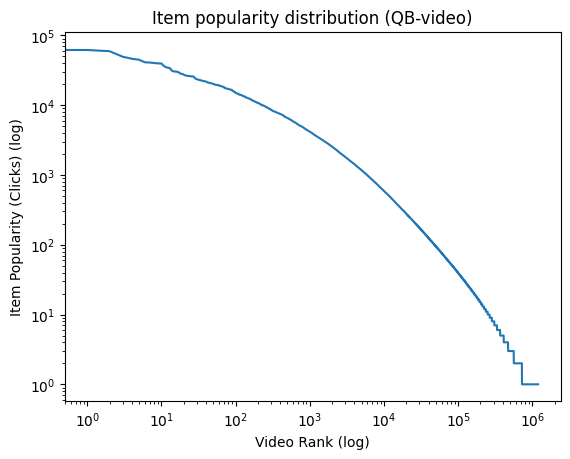

In [3]:
plt.figure()
plt.loglog(item_pop["video_rank"], item_pop["num_clicks"])
plt.xlabel("Video Rank (log)")
plt.ylabel("Item Popularity (Clicks) (log)")
plt.title("Item popularity distribution (QB-video)")
plt.show()

maximum session length: 867
average session length: 38.30
Precentage of users with session length [0-20] 37.63
Precentage of users with session length [0-50] 76.26


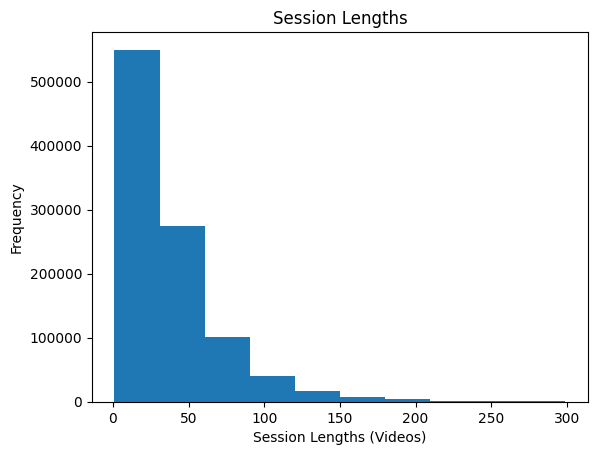

In [4]:
sessions = df.group_by("user_id").agg(pl.len().alias("session_length")).collect()
mean_len = sessions["session_length"].mean()
max_len = sessions["session_length"].max()
pct20 = sessions.filter(pl.col("session_length").is_between(0, 20, closed="both")).height / sessions.height * 100
pct50 = sessions.filter(pl.col("session_length").is_between(0, 50, closed="both")).height / sessions.height * 100

print(f"maximum session length: {max_len}")
print(f"average session length: {mean_len:.2f}")
print(f"Precentage of users with session length [0-20] {pct20:.2f}")
print(f"Precentage of users with session length [0-50] {pct50:.2f}")

session_filter = sessions.filter(pl.col("session_length") < 300)
plt.figure()
plt.hist(session_filter["session_length"], bins=10)
plt.xlabel("Session Lengths (Videos)")
plt.ylabel("Frequency")
plt.title("Session Lengths")
plt.show()

In [5]:
summary = df.select([
    pl.n_unique("user_id").alias("num_users"),
    pl.n_unique("item_id").alias("num_items"),
    pl.count().alias("num_rows"),
]).collect()
summary_row = summary.row(0, named=True)
num_users = summary_row["num_users"]
num_items = summary_row["num_items"]
num_rows = summary_row["num_rows"]
print(f"Total number of users: {num_users}")
print(f"Total number of unique pieces of content: {num_items}")
print(f"Total number of lines in the file: {num_rows}")


/var/folders/jj/wd836_8n6j764tsdk750fh240000gn/T/ipykernel_67300/116656848.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("num_rows"),


Total number of users: 1000000
Total number of unique pieces of content: 1197009
Total number of lines in the file: 38300254


/Users/home/Documents/tenrec/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/home/Documents/tenrec/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


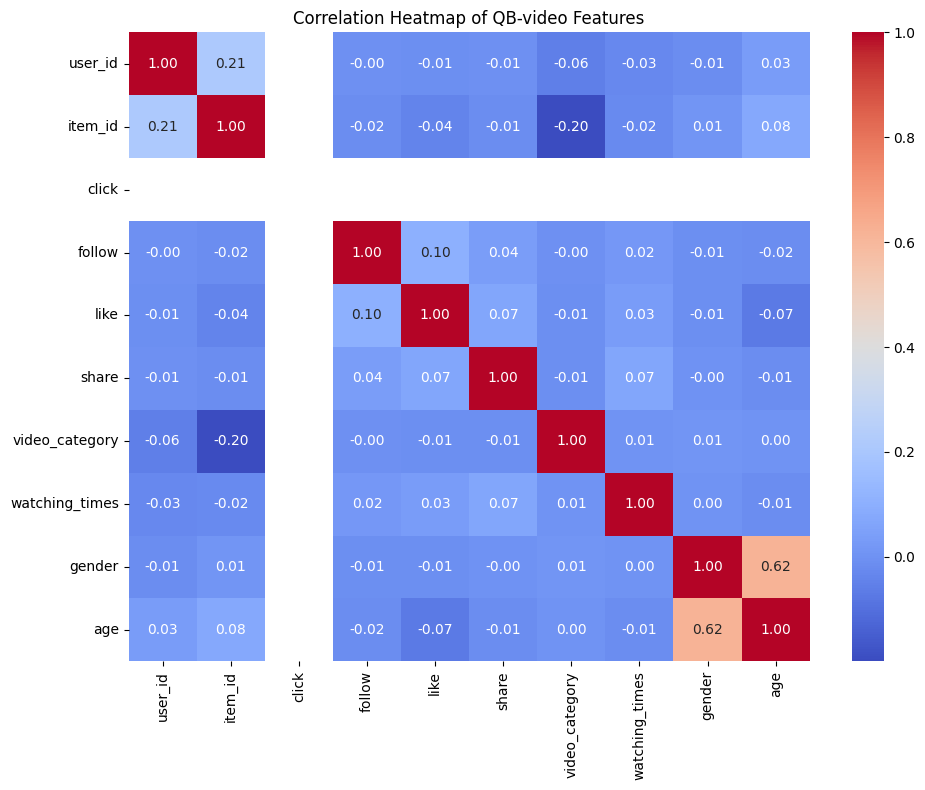

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

full_df = df.collect()
numeric_df = full_df.select([
    pl.col(col).cast(pl.Float64, strict=False).alias(col) for col in full_df.columns
])
numeric_df = numeric_df.fill_null(strategy="mean")

feature_matrix = numeric_df.to_numpy()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)
correlation_matrix = np.corrcoef(scaled_features, rowvar=False)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    xticklabels=numeric_df.columns,
    yticklabels=numeric_df.columns,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
)
plt.title('Correlation Heatmap of QB-video Features')
plt.tight_layout()
plt.show()
